In [18]:
def leer_fichero(nombre_archivo):
    """
    Lee el contenido completo de un fichero.

    Args:
        nombre_archivo (str): Ruta o nombre del fichero que se desea abrir.

    Returns:
        str: Contenido completo del fichero como una cadena de texto.
    """
    with open(nombre_archivo, 'r', encoding='utf-8') as archivo:
        contenido = archivo.read()
    return contenido

In [4]:
import string

def normalizar_texto(texto):
    """
    Convierte un texto a minúsculas y elimina signos de puntuación del español.

    Args:
        texto (str): Texto de entrada.

    Returns:
        str: Texto en minúsculas sin signos de puntuación.
    """
    signos = string.punctuation + "¡¿"
    tabla = str.maketrans('', '', signos)
    return texto.lower().translate(tabla)


In [6]:
import timeit

# Texto de prueba
texto = (
    "Python es genial. "
    "Este texto contiene varias letras que queremos reemplazar. "
    "aaaaa eeeee iiiii ooooo uuuuu "
    "Python es genial. "
) * 1000

# Caso 1: reemplazo simple
def usar_replace_simple():
    return texto.replace("a", "b")

tabla_simple = str.maketrans({"a": "b"})

def usar_translate_simple():
    return texto.translate(tabla_simple)

# Caso 2: varios reemplazos de caracteres
def usar_replace_multiple():
    resultado = texto
    resultado = resultado.replace("a", "b")
    resultado = resultado.replace("e", "f")
    resultado = resultado.replace("i", "j")
    resultado = resultado.replace("o", "k")
    resultado = resultado.replace("u", "l")
    return resultado

tabla_multiple = str.maketrans({
    "a": "b",
    "e": "f",
    "i": "j",
    "o": "k",
    "u": "l",
})

def usar_translate_multiple():
    return texto.translate(tabla_multiple)

# Medición
n = 1000

tiempo_replace_simple = timeit.timeit(usar_replace_simple, number=n)
tiempo_translate_simple = timeit.timeit(usar_translate_simple, number=n)

tiempo_replace_multiple = timeit.timeit(usar_replace_multiple, number=n)
tiempo_translate_multiple = timeit.timeit(usar_translate_multiple, number=n)

print("=== Reemplazo simple ===")
print(f"replace:   {tiempo_replace_simple:.6f} s")
print(f"translate: {tiempo_translate_simple:.6f} s")

print("\n=== Múltiples reemplazos ===")
print(f"replace:   {tiempo_replace_multiple:.6f} s")
print(f"translate: {tiempo_translate_multiple:.6f} s")

=== Reemplazo simple ===
replace:   0.044966 s
translate: 0.061101 s

=== Múltiples reemplazos ===
replace:   0.232300 s
translate: 0.061590 s


In [8]:
def tokeniza_palabras(texto):
    return texto.split()

texto = "Python es un lenguaje de programación muy popular."
texto = normalizar_texto(texto)
print(texto)
texto = tokeniza_palabras(texto)
print(texto)

python es un lenguaje de programación muy popular
['python', 'es', 'un', 'lenguaje', 'de', 'programación', 'muy', 'popular']


In [9]:
def contar_frecuencia_palabras(texto):
    frecuencia = {}
    for palabra in texto:
        if palabra in frecuencia:
            frecuencia[palabra] += 1
        else:
            frecuencia[palabra] = 1
    return frecuencia

texto = "Python es un lenguaje de programación muy popular. Python es fácil de aprender."
texto = normalizar_texto(texto)
palabras = tokeniza_palabras(texto)
frecuencia = contar_frecuencia_palabras(palabras)
print(frecuencia)

{'python': 2, 'es': 2, 'un': 1, 'lenguaje': 1, 'de': 2, 'programación': 1, 'muy': 1, 'popular': 1, 'fácil': 1, 'aprender': 1}


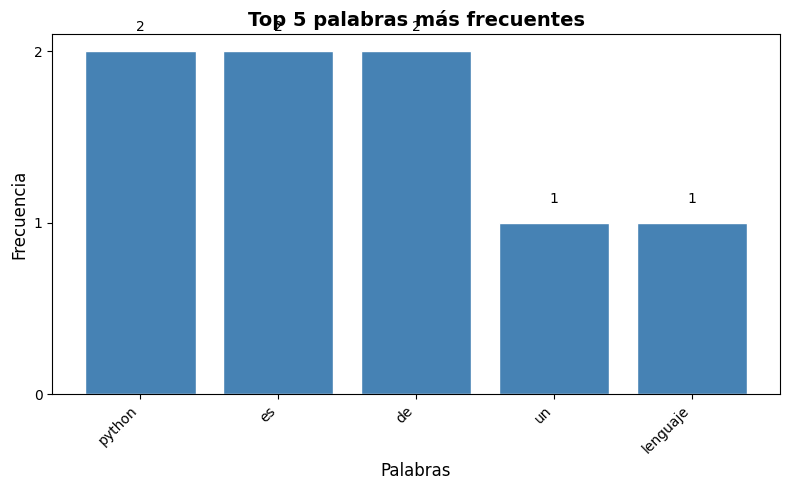

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def graficar_frecuencias(frecuencias, n_palabras):
    """
    Muestra un gráfico de barras con las N palabras más frecuentes.

    Args:
        frecuencias (dict): Diccionario con palabras como clave y su frecuencia como valor.
        n_palabras (int): Número de palabras más frecuentes a mostrar en el gráfico.
    """
    # Ordenar por frecuencia descendente y tomar las N primeras
    palabras_ordenadas = sorted(frecuencias.items(), key=lambda x: x[1], reverse=True)[:n_palabras]
    palabras, conteos = zip(*palabras_ordenadas)

    fig, ax = plt.subplots(figsize=(max(8, n_palabras), 5))

    barras = ax.bar(palabras, conteos, color="steelblue", edgecolor="white")

    # Etiqueta de valor encima de cada barra
    for barra, conteo in zip(barras, conteos):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.1,
            str(conteo),
            ha="center",
            va="bottom",
            fontsize=10,
        )

    ax.set_title(f"Top {n_palabras} palabras más frecuentes", fontsize=14, fontweight="bold")
    ax.set_xlabel("Palabras", fontsize=12)
    ax.set_ylabel("Frecuencia", fontsize=12)
    ax.set_xticks(range(len(palabras)))
    ax.set_xticklabels(palabras, rotation=45, ha="right", fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

# Ejemplo de uso con las frecuencias calculadas anteriormente
graficar_frecuencias(frecuencia, n_palabras=5)

Total de palabras            : 100231
Vocabulario único (tokens)   : 12646


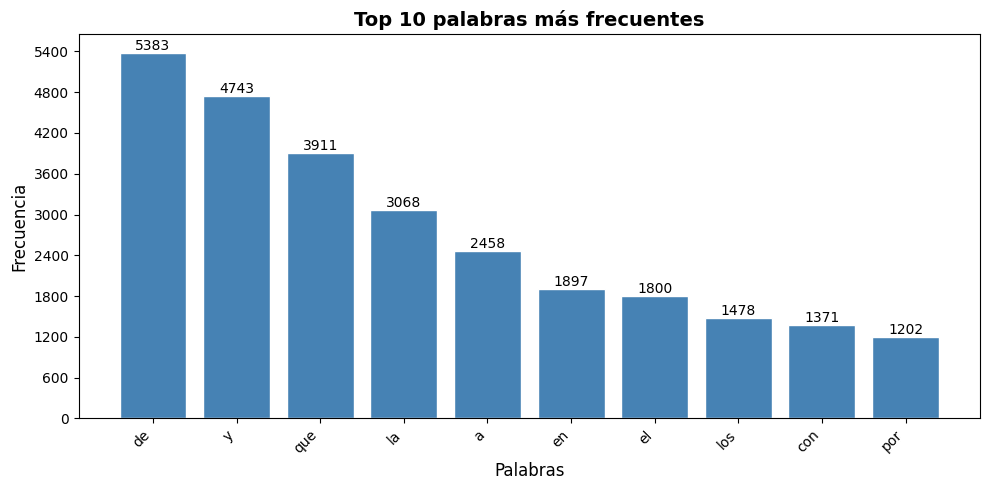

In [19]:
# ── Pipeline completo sobre pg66591.txt ──────────────────────────────────────

# 1. Leer el fichero
contenido = leer_fichero("pg66591.txt")

# 2. Normalizar (minúsculas + eliminar puntuación)
contenido_limpio = normalizar_texto(contenido)

# 3. Tokenizar
tokens = tokeniza_palabras(contenido_limpio)

# 4. Calcular frecuencias
frecuencias_libro = contar_frecuencia_palabras(tokens)

print(f"Total de palabras            : {len(tokens)}")
print(f"Vocabulario único (tokens)   : {len(frecuencias_libro)}")

# 5. Mostrar las 10 palabras más frecuentes en un gráfico de barras
graficar_frecuencias(frecuencias_libro, n_palabras=10)